# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *
from data_operations_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran


from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from sklearn.metrics import r2_score

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data

In [3]:
df_names_list = [
    'gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 
    'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 
    'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'
    ]
connection_link_var = repo_path_r_string + r'\03_simulated_data\simulated_data.sqlite'

In [4]:
dict_of_gdfs = {}
for i in df_names_list:
        gdf = import_spatial_point_data_frame(
                connection_link_lnx = repo_path_unix+"/03_simulated_data/simulated_data.sqlite",
                layer_name =i,
                crs_param = 3857
                                        )
        df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  f'{i}_sp'
                                        )
        df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
        gdf2 = gdf.merge(df2, on = ['unit_id'])
        dict_of_gdfs[i] = gdf2

In [5]:
gdf_pre =dict_of_gdfs['gdf_rho_0_75'].copy()
gdf = gdf_pre.drop(columns = [c for c in dict_of_gdfs['gdf_rho_0_75'].columns.tolist() if 'spatial_predictor' in c]).copy()
df = import_non_spatial_data_frame(
                connection_link = connection_link_var,
                df_to_return_name =  'gdf_rho_0_75_sp_t_dr5'
                                        )

df2 = df[['unit_id']+[c for c in df.columns.tolist() if 'spatial_predictor' in c]].copy()
gdf2 = gdf.merge(df2, on = ['unit_id'])

In [6]:
dict_of_gdfs['gdf_rho_0_75'].isna().any().any()

np.False_

In [7]:
dict_of_gdfs.keys()

dict_keys(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

# Modelling causal inference

## Single df

### Data preparation

In [8]:
X_ns = gdf2[["c1","c2",
         ]].values
X = gdf2[["c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]].values
y = gdf2["y"].values.reshape(-1,1)
T = gdf2["t"].values


T_tot = gdf2["t_tot"].values
Xdf = gdf2[['t','odr_1','odr_2','odr_3',
            #'odr_4', 
            "c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]]
Xdf2 = gdf2[['t','odr_1','odr_2','odr_3',
             #'odr_4', 
             "c1","c2",
         #"C3","Cs"
         ]]
Xdf3 = gdf2[['t',
            #'odr_4', 
            "c1","c2",
         'spatial_predictor_100_1',
    'spatial_predictor_100_3',
    'spatial_predictor_100_4',
    'spatial_predictor_100_2',
    'spatial_predictor_100_6',
    'spatial_predictor_100_5',
    'spatial_predictor_100_9',
    'spatial_predictor_500_9',
    'spatial_predictor_100_10'
         ]]

Xdf4 = gdf2[['t',
            #'odr_4', 
            "c1","c2",
         ]]

X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
X_l3 = sm.add_constant(Xdf3)
X_l4 = sm.add_constant(Xdf4)
y_l = gdf2["y_ns"]
Y = gdf2['y'].values

gdf3 = gdf2.copy()

gdf3["t_catS"] = gdf3['t']
gdf3["t_catS"] = gdf3["t_catS"].replace({
    0: "control",
    1: "inner_ring"
})

T_S= gdf3['t_catS'].values

gdf3['t_tot_cat3'] = gdf3['t_tot_cat']
gdf3.loc[gdf3['t_tot_cat']=='treated_outer_ring4', 't_tot_cat3'] = 'control'

T_M= gdf3['t_tot_cat3'].values
T_M= T_M.astype(str)

gdf4 = gdf2.copy()[['unit_id',
            't',
            'propensity',
            't_tot', 't_tot_cat']]
gdf4.loc[(gdf4['t_tot'] == 1)&(gdf4['t'] != 1), 't_double']= 1
gdf4['t_double_cat'] = gdf4['t_tot_cat'].replace({ 
    'treated_outer_ring4':'control',
     'treated_outer_ring3':'treated_outer_ring',                                             
      'treated_outer_ring2':'treated_outer_ring',
      'treated_outer_ring1':'treated_outer_ring',                                            
                                                  })
gdf4 = gdf4.fillna(0)



T_Dbl= gdf4['t_double_cat'].values
T_Dbl= T_Dbl.astype(str)

gdf3 = gdf3.rename(columns = {'t': 'treated_inner_ring',
                              'odr_1':'treated_outer_ring1', 
                              'odr_2':'treated_outer_ring2', 
                              'odr_3':'treated_outer_ring3', 
                              'odr_4':'treated_outer_ring4'
                              })
T_mult = gdf3[[ 
         'treated_inner_ring', 'treated_outer_ring1','treated_outer_ring2','treated_outer_ring3',
         #'treated_outer_ring4'
         ]].to_numpy()

gdf5 = gdf4.copy()


gdf5 = gdf5.rename(columns = {'t': 'treated_inner_ring',
                              't_double':'treated_outer_rings', 
                              })

T_DT = gdf5[[ 
         'treated_inner_ring', 'treated_outer_rings'
         ]].to_numpy()


gdf6 = gdf2[['unit_id',
    't',
    't_tot',
    't_tot_cat',
    'odr_1',
    'odr_2',
    'odr_3',
    ]]
gdf6['dr1'] = gdf6['odr_1'] 
gdf6['dr2'] = gdf6['odr_2'] /2
gdf6['dr3'] = gdf6['odr_3'] /3
gdf6['treated_outer_rings'] = gdf6['dr1'] + gdf6['dr2'] + gdf6['dr3']
gdf6['treated_inner_ring'] = gdf6['t']

T_DT_id = gdf6[[ 
         'treated_inner_ring', 'treated_outer_rings'
         ]].to_numpy()

gdf2_22 = gdf.copy()
gdf2_22["x"] = gdf2_22.geometry.x.astype(int)
gdf2_22["y"] = gdf2_22.geometry.y.astype(int)

n = len(gdf2_22)

coords = np.array(
        list(zip(gdf2_22["x"], gdf2_22["y"]))
    )


W_mat = DistanceBand(
        coords,
        threshold=100 + 1,
        binary=True,
        silence_warnings=True
    ) 

C:\Users\andre\AppData\Local\Temp\ipykernel_26556\3937043047.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf6['dr1'] = gdf6['odr_1']
C:\Users\andre\AppData\Local\Temp\ipykernel_26556\3937043047.py:129: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf6['dr2'] = gdf6['odr_2'] /2
C:\Users\andre\AppData\Local\Temp\ipykernel_26556\3937043047.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [9]:
replacing_dict_0_ring = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                            #4:'treated_outer_ring4'
                                             }

replacing_dict_odr_ring = {'t':'treated_inner_ring', 
                                                                        'odr_1':'treated_outer_ring1', 
                                                                        'odr_2':'treated_outer_ring2',
                                                                        'odr_3':'treated_outer_ring3',
                                                                          #'odr_4':'treated_outer_ring4'
                                                                          }

### Multi treatment

#### With spatial regressors

##### S learner

In [10]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT, lb_slearn_multT, ub_slearn_multT = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite_slearn_multT = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df_slearn_multT = pd.DataFrame(ite_slearn_multT).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_multT['treated'] = T_M
ITE_df_slearn_multT['ITE_real'] = gdf2['tau']
ITE_df_slearn_multT['Y'] = Y
ITE_df_slearn_multT

,treated_inner_ring,treated_outer_ring1,treated_outer_ring2,treated_outer_ring3,treated,ITE_real,Y
0,0.222360,0.384104,0.008172,0.004287,control,0.0,3.583302
1,1.466920,1.092709,0.062885,0.004194,control,0.0,1.664774
2,1.545003,0.558422,0.067997,-0.002160,control,0.0,0.924681
3,2.918534,1.889261,0.127504,0.020668,control,0.0,-1.424234
4,2.253641,1.110219,0.170300,0.041785,control,0.0,0.939380
...,...,...,...,...,...,...,...
795,1.333539,0.214520,0.005981,0.000805,control,0.0,0.515627
796,2.148403,1.449596,0.033977,0.016667,control,0.0,-0.243606
797,2.372510,0.051316,-0.011038,0.007522,control,0.0,-0.990687
798,1.525693,1.140704,0.100166,0.021084,control,0.0,0.898532


In [11]:
df_effectbase = pd.DataFrame({
                'ring':['treated_inner_ring', 'treated_outer_ring1', 'treated_outer_ring2','treated_outer_ring3',
                        #'treated_outer_ring4'
                        ],
              'true_effect':[gdf2[gdf2['t'] == 1]['tau'].mean(), gdf2[gdf2['odr_1'] == 1]['tau'].mean(), 
                             gdf2[gdf2['odr_2'] == 1]['tau'].mean(), gdf2[gdf2['odr_3'] == 1]['tau'].mean(), 
                               #gdf2[gdf2['odr_4'] == 1]['tau'].mean()
                               ],
              })
df_multi_treatment_effects_Slearn = make_treatment_effects_df(ITE_df_slearn_multT,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_sp', treated_col='treated')
df_multi_effect_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn, on = 'ring', how= 'left')
df_multi_effect_pre1

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp
0,treated_inner_ring,1.500000,1.554898,0.072790
1,treated_outer_ring1,1.049929,0.756394,0.074071
2,treated_outer_ring2,0.535380,0.040590,0.009621
3,treated_outer_ring3,0.123083,0.012758,0.002603


##### Linear DML

In [12]:
est_LDML = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML.fit(Y, T_mult, X=X, 
        #W=W
        )
te_pred_LDML = est_LDML.const_marginal_effect(X)

ITE_LDML= pd.DataFrame(te_pred_LDML).rename(columns = replacing_dict_0_ring)
ITE_LDML['treated'] = T_M
df_multi_treatment_effects_LDML = make_treatment_effects_df(ITE_LDML,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_sp', treated_col='treated')
df_multi_effect_pre2 = df_multi_effect_pre1.merge(df_multi_treatment_effects_LDML, on = 'ring', how= 'left')
df_multi_effect_pre2 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp
0,treated_inner_ring,1.500000,1.554898,0.072790,-10.943185,1.827864
1,treated_outer_ring1,1.049929,0.756394,0.074071,1.381278,0.679749
2,treated_outer_ring2,0.535380,0.040590,0.009621,-0.292196,0.334440
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.300041,0.171010


##### Causal forest

In [13]:
est2 = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

te_pred2 = est2.const_marginal_effect(X)
ITE_CF=pd.DataFrame(te_pred2).rename(columns = replacing_dict_0_ring)
ITE_CF['treated'] = T_M
df_multi_treatment_effects_CF = make_treatment_effects_df(ITE_CF,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_sp', treated_col='treated')
df_multi_effect_pre3 = df_multi_effect_pre2.merge(df_multi_treatment_effects_CF, on = 'ring', how= 'left')
df_multi_effect_pre3 

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp
0,treated_inner_ring,1.500000,1.554898,0.072790,-10.943185,1.827864,1.109024,0.024768
1,treated_outer_ring1,1.049929,0.756394,0.074071,1.381278,0.679749,0.914845,0.019377
2,treated_outer_ring2,0.535380,0.040590,0.009621,-0.292196,0.334440,0.071479,0.034786
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.300041,0.171010,0.006354,0.024581


##### Cross sectional DiD with spatial predictors

In [14]:
model_cs_did_sp_pred = sm.OLS(y_l, X_l)
results_cs_did_sp_pred = model_cs_did_sp_pred.fit()

coef_df_cs_did_sp_pred = pd.DataFrame({
    "ring": results_cs_did_sp_pred.params.index,
    "att_mDiD_sp_pred": results_cs_did_sp_pred.params.values,
    "se_mDiD_sp_pred": results_cs_did_sp_pred.bse.values
})
coef_df_cs_did_sp_pred = coef_df_cs_did_sp_pred[coef_df_cs_did_sp_pred['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did_sp_pred['ring'] = coef_df_cs_did_sp_pred['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_pre4 = df_multi_effect_pre3.merge(coef_df_cs_did_sp_pred, on = 'ring', how= 'left')
df_multi_effect_pre4

,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred
0,treated_inner_ring,1.500000,1.554898,0.072790,-10.943185,1.827864,1.109024,0.024768,1.294492,0.130124
1,treated_outer_ring1,1.049929,0.756394,0.074071,1.381278,0.679749,0.914845,0.019377,0.994052,0.157574
2,treated_outer_ring2,0.535380,0.040590,0.009621,-0.292196,0.334440,0.071479,0.034786,0.237278,0.148948
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.300041,0.171010,0.006354,0.024581,0.178040,0.136176


##### SDM DiD

In [15]:
did_sdm_ysp = ML_Lag(
    y,
    X_l2,
    w=W_mat,              
    slx_lags=0,       
    name_y="y",
    # name_x=['t','odr_1','odr_2','odr_3','odr_4', "c1","c2"
    #         ]
)

did_sdm_ysp_coefs = did_sdm_ysp.betas.flatten()
did_sdm_ysp_ses = np.sqrt(np.diag(did_sdm_ysp.vm))
did_sdm_ysp_variables = did_sdm_ysp.name_x.copy()

coef_did_sdm_ysp = pd.DataFrame({
    "ring": did_sdm_ysp_variables,
    "att_sdm": did_sdm_ysp_coefs,
    "att_sdm_se": did_sdm_ysp_ses 
})
coef_did_sdm_ysp = coef_did_sdm_ysp[coef_did_sdm_ysp['ring'].isin(['t', 'odr_1', 'odr_2', 'odr_3'])]
coef_did_sdm_ysp['ring'] = coef_did_sdm_ysp['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_sp_regr = df_multi_effect_pre4.merge(coef_did_sdm_ysp, on = 'ring', how= 'left')
df_multi_effect_sp_regr

ML_Lag


,ring,true_effect,att_mSlearn_sp,se_mSlearn_sp,att_mLDML_sp,se_mLDML_sp,att_mCF_sp,se_mCF_sp,att_mDiD_sp_pred,se_mDiD_sp_pred,att_sdm,att_sdm_se
0,treated_inner_ring,1.500000,1.554898,0.072790,-10.943185,1.827864,1.109024,0.024768,1.294492,0.130124,1.400015,0.115569
1,treated_outer_ring1,1.049929,0.756394,0.074071,1.381278,0.679749,0.914845,0.019377,0.994052,0.157574,1.053377,0.145766
2,treated_outer_ring2,0.535380,0.040590,0.009621,-0.292196,0.334440,0.071479,0.034786,0.237278,0.148948,0.275588,0.135243
3,treated_outer_ring3,0.123083,0.012758,0.002603,0.300041,0.171010,0.006354,0.024581,0.178040,0.136176,0.210737,0.124276


##### Results visualization

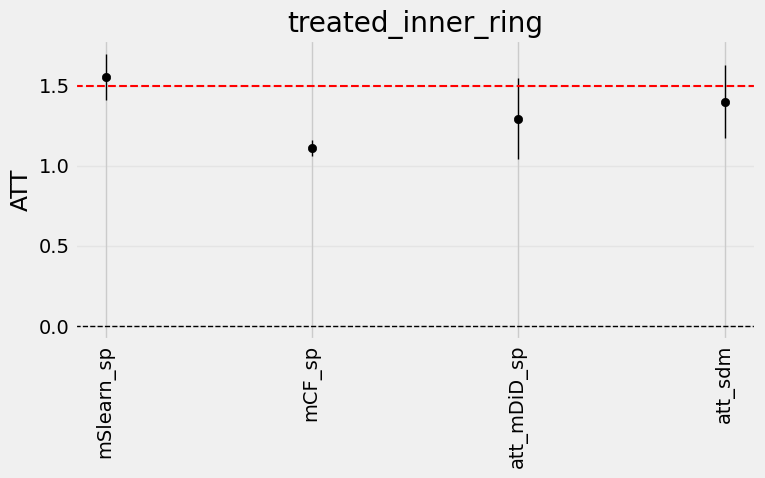

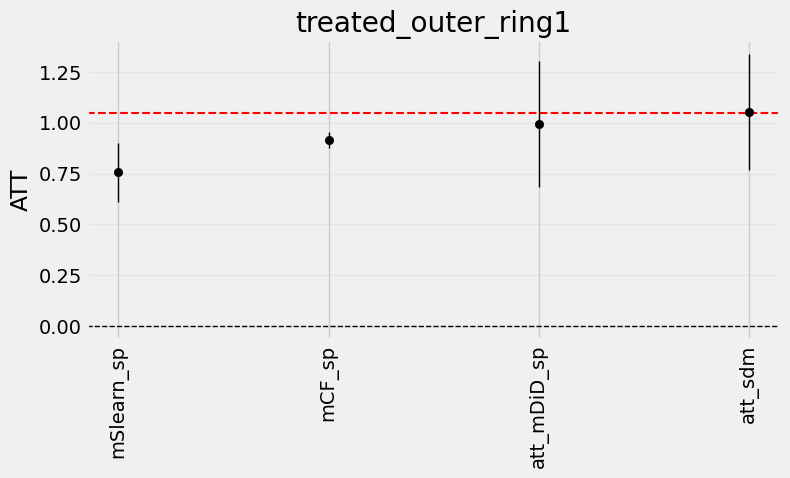

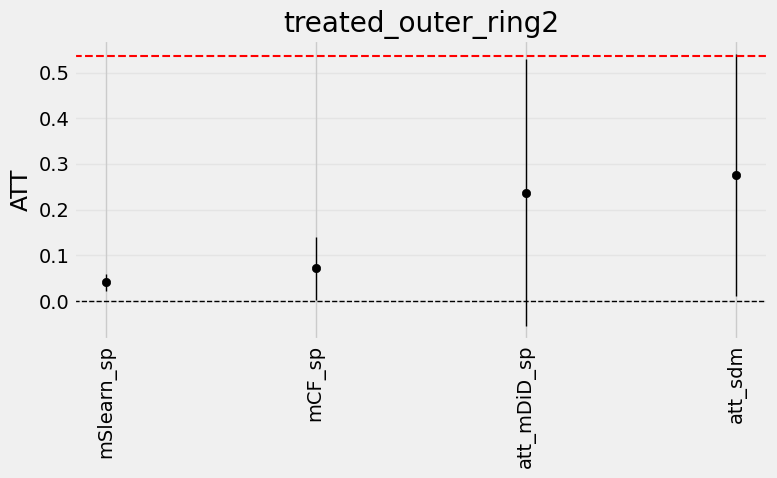

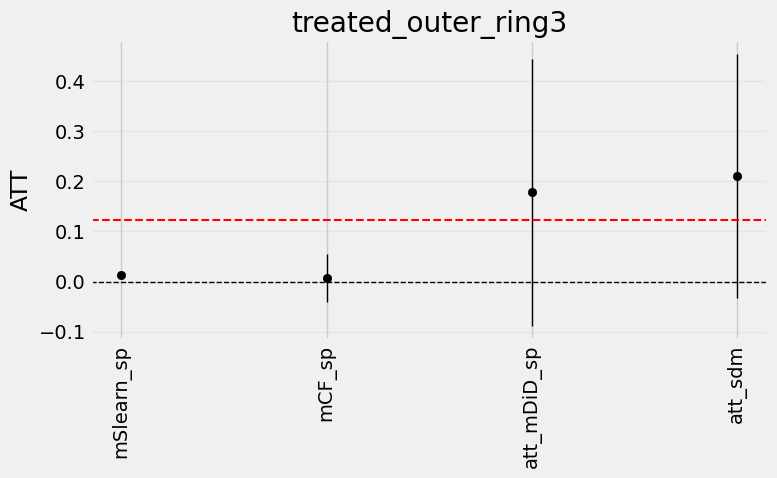

In [16]:
att_models_sp = {
    "mSlearn_sp": ("att_mSlearn_sp", "se_mSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "mCF_sp": ("att_mCF_sp", "se_mCF_sp"),
    "att_mDiD_sp": ("att_mDiD_sp_pred", "se_mDiD_sp_pred"),
    "att_sdm": ("att_sdm", "att_sdm_se"),
    # "mSlearn_nsp": ("att_mSlearn_nsp", "se_mSlearn_nsp"),
    # #"mLDML_nsp": ("att_mLDML_nsp", "se_mLDML_nsp"),
    # "mCF_nsp": ("att_mCF_nsp", "se_mCF_nsp"),
    # "att_mDiD": ("att_mDiD", "se_mDiD")
}
for ring in df_multi_effect_sp_regr['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_sp_regr,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_sp
    )

#### Without spatial regressors

##### S learner

In [17]:
RF_s_learner_nsp = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp, lb_slearn_multT_nsp, ub_slearn_multT_nsp = RF_s_learner.estimate_ate(X_ns, T_M, Y, return_ci = True)
ite_slearn_multT_nsp = RF_s_learner_nsp.fit_predict(X_ns, T_M, Y)
ITE_df_slearn_multT_nsp = pd.DataFrame(ite_slearn_multT_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_df_slearn_multT_nsp['treated'] = T_M
df_multi_treatment_effects_Slearn_nsp = make_treatment_effects_df(ITE_df_slearn_multT_nsp,  [ 'treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mSlearn_nsp', treated_col='treated')
df_multi_effect_nspreg_pre1 = df_effectbase.merge(df_multi_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre1

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp
0,treated_inner_ring,1.500000,1.678903,0.079561
1,treated_outer_ring1,1.049929,1.036443,0.096466
2,treated_outer_ring2,0.535380,0.160635,0.031481
3,treated_outer_ring3,0.123083,0.036636,0.019207


##### Linear DML

In [18]:
est_LDML_nsp = LinearDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)

est_LDML_nsp.fit(Y, T_mult, X=X_ns, 
        #W=W
        )
te_pred_LDML_nsp = est_LDML_nsp.const_marginal_effect(X_ns)

ITE_LDML_nsp= pd.DataFrame(te_pred_LDML_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_LDML_nsp['treated'] = T_M
df_multi_treatment_effects_LDML_nsp = make_treatment_effects_df(ITE_LDML_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mLDML_nsp', treated_col='treated')
df_multi_effect_nspreg_pre2 = df_multi_effect_nspreg_pre1.merge(df_multi_treatment_effects_LDML_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre2 

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp
0,treated_inner_ring,1.500000,1.678903,0.079561,1.664563,0.044819
1,treated_outer_ring1,1.049929,1.036443,0.096466,1.196937,0.088488
2,treated_outer_ring2,0.535380,0.160635,0.031481,0.390104,0.069668
3,treated_outer_ring3,0.123083,0.036636,0.019207,0.206161,0.039434


##### Causal forest

In [19]:
est2_cf_nsp = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp.tune(Y, T_mult, X=X_ns, 
          #W=W
          )
est2_cf_nsp.fit(Y, T_mult, X=X_ns, 
         #W=W
         )

te_pred2_nsp = est2_cf_nsp.const_marginal_effect(X_ns)
ITE_CF_nsp=pd.DataFrame(te_pred2_nsp).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_ring1', 
                                             2:'treated_outer_ring2', 3:'treated_outer_ring3',
                                             #4:'treated_outer_ring4'
                                             })
ITE_CF_nsp['treated'] = T_M
df_multi_treatment_effects_CF_nsp = make_treatment_effects_df(ITE_CF_nsp,  ['treated_inner_ring','treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'mCF_nsp', treated_col='treated')
df_multi_effect_nspreg_pre3 = df_multi_effect_nspreg_pre2.merge(df_multi_treatment_effects_CF_nsp, on = 'ring', how= 'left')
df_multi_effect_nspreg_pre3

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp
0,treated_inner_ring,1.500000,1.678903,0.079561,1.664563,0.044819,1.638037,0.024749
1,treated_outer_ring1,1.049929,1.036443,0.096466,1.196937,0.088488,1.154055,0.028321
2,treated_outer_ring2,0.535380,0.160635,0.031481,0.390104,0.069668,0.420485,0.040353
3,treated_outer_ring3,0.123083,0.036636,0.019207,0.206161,0.039434,0.231519,0.014950


##### DiD without spatial predictors

In [20]:
model_cs_did = sm.OLS(y_l, X_l2)
results_cs_did = model_cs_did.fit()

coef_df_cs_did = pd.DataFrame({
    "ring": results_cs_did.params.index,
    "att_mDiD": results_cs_did.params.values,
    "se_mDiD": results_cs_did.bse.values
})
coef_df_cs_did = coef_df_cs_did[coef_df_cs_did['ring'].isin(['t', 
                                                            'odr_1', 'odr_2',
                                                            'odr_3',
                                                             # 'odr_4'
                                                            ])].copy()

coef_df_cs_did['ring'] = coef_df_cs_did['ring'].replace(replacing_dict_odr_ring)
df_multi_effect_nspreg = df_multi_effect_nspreg_pre3.merge(coef_df_cs_did, on = 'ring', how= 'left')
df_multi_effect_nspreg

,ring,true_effect,att_mSlearn_nsp,se_mSlearn_nsp,att_mLDML_nsp,se_mLDML_nsp,att_mCF_nsp,se_mCF_nsp,att_mDiD,se_mDiD
0,treated_inner_ring,1.500000,1.678903,0.079561,1.664563,0.044819,1.638037,0.024749,1.394253,0.094544
1,treated_outer_ring1,1.049929,1.036443,0.096466,1.196937,0.088488,1.154055,0.028321,1.063688,0.139080
2,treated_outer_ring2,0.535380,0.160635,0.031481,0.390104,0.069668,0.420485,0.040353,0.287851,0.133734
3,treated_outer_ring3,0.123083,0.036636,0.019207,0.206161,0.039434,0.231519,0.014950,0.205953,0.124498


#### Results visualization

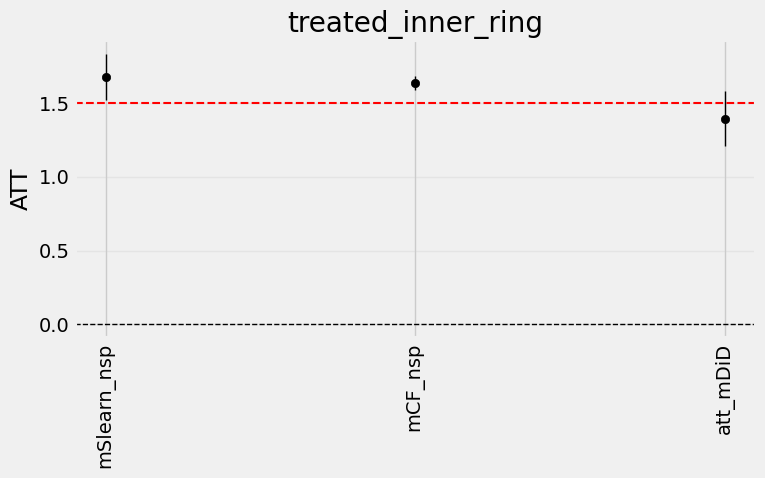

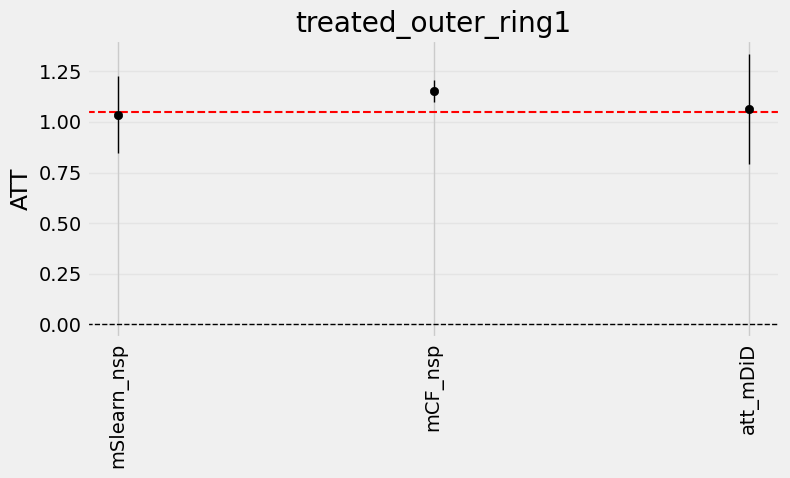

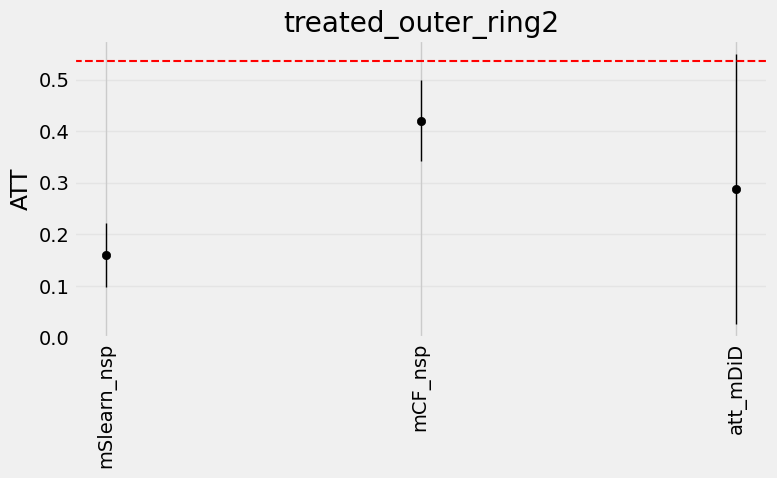

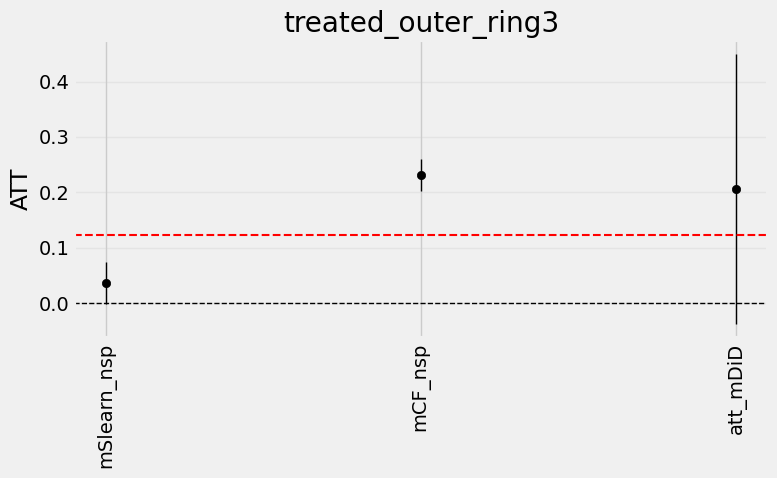

In [21]:
att_models_nspreg = {
    "mSlearn_nsp": ("att_mSlearn_nsp", "se_mSlearn_nsp"),
    #"mLDML_nsp": ("att_mLDML_nsp", "se_mLDML_nsp"),
    "mCF_nsp": ("att_mCF_nsp", "se_mCF_nsp"),
    "att_mDiD": ("att_mDiD", "se_mDiD")
}
for ring in df_multi_effect_nspreg['ring'].unique().tolist():
    plot_att_row(
        df=df_multi_effect_nspreg,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_nspreg
    )

### Single treatment

#### With spatial regressors

##### S learner

In [22]:
RF_s_learnerS = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_Sngl, lb_slearn_Sngl, ub_slearn_Sngl = RF_s_learnerS.estimate_ate(X, T_S, Y, return_ci = True)
ite_slearn_Sngl = RF_s_learnerS.fit_predict(X, T_S, Y)
ITE_df_slearn_Sngl = pd.DataFrame(ite_slearn_Sngl).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_Sngl['treated'] = T_M
ITE_df_slearn_Sngl['ITE_real'] = gdf2['tau']
ITE_df_slearn_Sngl['Y'] = Y
ITE_df_slearn_Sngl

,treated_inner_ring,treated,ITE_real,Y
0,0.151444,control,0.0,3.583302
1,1.377374,control,0.0,1.664774
2,1.240494,control,0.0,0.924681
3,2.460353,control,0.0,-1.424234
4,1.795364,control,0.0,0.939380
...,...,...,...,...
795,0.969759,control,0.0,0.515627
796,1.634265,control,0.0,-0.243606
797,1.790237,control,0.0,-0.990687
798,1.184871,control,0.0,0.898532


In [23]:
df_single_treatment_effects_SlearnS = make_treatment_effects_df(ITE_df_slearn_Sngl,  [ 'treated_inner_ring',
             ],'sSlearn_sp', treated_col='treated')
df_single_effect_pre1 = df_effectbase[df_effectbase['ring'] == 'treated_inner_ring'].merge(df_single_treatment_effects_SlearnS, on = 'ring', how= 'left')
df_single_effect_pre1

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp
0,treated_inner_ring,1.5,0.876873,0.057116


In [24]:
ITE_df_slearn_Sngl['treated'].unique()

array(['control', 'treated_outer_ring3', 'treated_outer_ring2',
       'treated_outer_ring1', 'treated_inner_ring'], dtype=object)

In [25]:
ITE_df_slearn_Sngl[ITE_df_slearn_Sngl['treated'] == 'treated_outer_ring1']

,treated_inner_ring,treated,ITE_real,Y
187,1.308726,treated_outer_ring1,0.404602,-2.118462
188,0.782655,treated_outer_ring1,1.137633,1.921481
189,1.216602,treated_outer_ring1,0.892787,0.019313
190,0.522108,treated_outer_ring1,0.650698,1.488744
191,0.654043,treated_outer_ring1,1.556221,2.874297
192,0.041441,treated_outer_ring1,1.340238,2.823090
193,0.333629,treated_outer_ring1,1.538729,3.187922
206,0.456541,treated_outer_ring1,0.901819,1.949785
214,0.478228,treated_outer_ring1,0.909078,2.608444
226,0.274999,treated_outer_ring1,1.812537,3.283955


##### Causal forest

In [26]:
est2S = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2S.tune(Y, T, X=X, 
          #W=W
          )
est2S.fit(Y, T, X=X, 
         #W=W
         )

te_pred2S = est2S.const_marginal_effect(X)
ITE_CFS=pd.DataFrame(te_pred2S).rename(columns = replacing_dict_0_ring)
ITE_CFS['treated'] = T_M
df_single_treatment_effects_CF = make_treatment_effects_df(ITE_CFS,  ['treated_inner_ring',
            # 'treated_outer_ring1',
            #  'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'sCF_sp', treated_col='treated')
df_single_effect_pre2 = df_single_effect_pre1.merge(df_single_treatment_effects_CF, on = 'ring', how= 'left')
df_single_effect_pre2

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp
0,treated_inner_ring,1.5,0.876873,0.057116,0.406766,0.016073


In [27]:
y_base = est2S.models_y[0][0].predict(X)
tau_hat = est2S.effect(X)

# final prediction
y_hat = y_base + tau_hat * T

# R²
r2 = r2_score(Y, y_hat)
r2

0.5369655346864455

##### DiD

In [28]:
model_cs_did_sp_pred_single = sm.OLS(y_l, X_l3)
results_cs_did_sp_pred_single = model_cs_did_sp_pred_single.fit()

coef_df_cs_did_sp_pred_single = pd.DataFrame({
    "ring": results_cs_did_sp_pred_single.params.index,
    "att_sDiD_sp_pred": results_cs_did_sp_pred_single.params.values,
    "se_sDiD_sp_pred": results_cs_did_sp_pred_single.bse.values
})
coef_df_cs_did_sp_pred_single = coef_df_cs_did_sp_pred_single[coef_df_cs_did_sp_pred_single['ring'].isin(['t'
                                                            ])].copy()

coef_df_cs_did_sp_pred_single['ring'] = coef_df_cs_did_sp_pred_single['ring'].replace(replacing_dict_odr_ring)
df_single_effect_final = df_single_effect_pre2.merge(coef_df_cs_did_sp_pred_single, on = 'ring', how= 'left')
df_single_effect_final

,ring,true_effect,att_sSlearn_sp,se_sSlearn_sp,att_sCF_sp,se_sCF_sp,att_sDiD_sp_pred,se_sDiD_sp_pred
0,treated_inner_ring,1.5,0.876873,0.057116,0.406766,0.016073,0.982883,0.113076


##### Resuts visualization

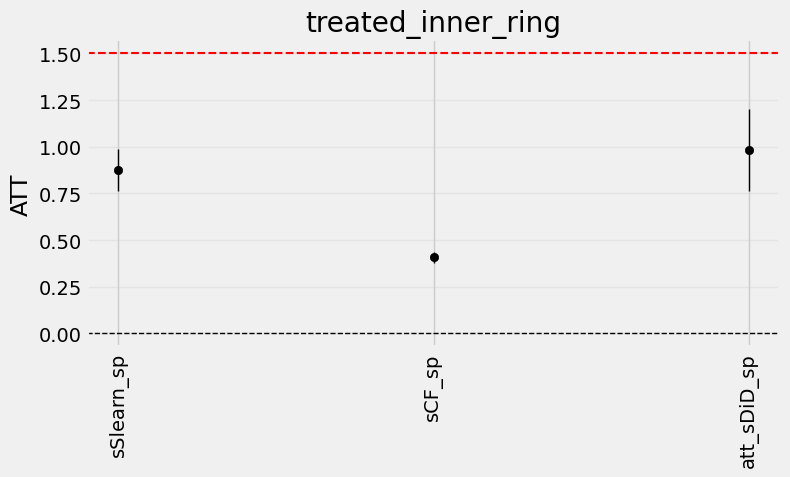

In [29]:
att_models_sp_single = {
    "sSlearn_sp": ("att_sSlearn_sp", "se_sSlearn_sp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "sCF_sp": ("att_sCF_sp", "se_sCF_sp"),
    "att_sDiD_sp": ("att_sDiD_sp_pred", "se_sDiD_sp_pred"),

}

plot_att_row(
        df=df_single_effect_final,
        ring_name='treated_inner_ring',
        true_effect_col="true_effect",
        att_dict=att_models_sp_single
    )

#### Without spatial regressors

##### S learner

In [30]:
RF_s_learnerS2 = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_Sngl2, lb_slearn_Sngl2, ub_slearn_Sngl2 = RF_s_learnerS.estimate_ate(X_ns, T_S, Y, return_ci = True)
ite_slearn_Sngl2 = RF_s_learnerS2.fit_predict(X_ns, T_S, Y)
ITE_df_slearn_Sngl2 = pd.DataFrame(ite_slearn_Sngl2).rename(columns = replacing_dict_0_ring)
ITE_df_slearn_Sngl2['treated'] = T_M
ITE_df_slearn_Sngl2['ITE_real'] = gdf2['tau']
ITE_df_slearn_Sngl2['Y'] = Y
ITE_df_slearn_Sngl2

,treated_inner_ring,treated,ITE_real,Y
0,0.413939,control,0.0,3.583302
1,1.644187,control,0.0,1.664774
2,1.296909,control,0.0,0.924681
3,2.518512,control,0.0,-1.424234
4,2.172394,control,0.0,0.939380
...,...,...,...,...
795,1.221475,control,0.0,0.515627
796,2.218438,control,0.0,-0.243606
797,2.421276,control,0.0,-0.990687
798,1.871250,control,0.0,0.898532


In [31]:
df_single_treatment_effects_SlearnS_nsp = make_treatment_effects_df(ITE_df_slearn_Sngl2,  [ 'treated_inner_ring',
             ],'sSlearn_nsp', treated_col='treated')
df_single_effect_ns_pre1 = df_effectbase[df_effectbase['ring'] == 'treated_inner_ring'].merge(df_single_treatment_effects_SlearnS_nsp, on = 'ring', how= 'left')
df_single_effect_ns_pre1

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp
0,treated_inner_ring,1.5,1.532228,0.070858


##### Causal forest

In [32]:
est2S_nsp = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2S_nsp.tune(Y, T, X=X_ns, 
          #W=W
          )
est2S_nsp.fit(Y, T, X=X_ns, 
         #W=W
         )

te_pred2S_nsp = est2S_nsp.const_marginal_effect(X_ns)
ITE_CFS_nsp=pd.DataFrame(te_pred2S_nsp).rename(columns = replacing_dict_0_ring)
ITE_CFS_nsp['treated'] = T_M
df_single_treatment_effects_CF_nsp = make_treatment_effects_df(ITE_CFS_nsp,  ['treated_inner_ring',
            # 'treated_outer_ring1',
            #  'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'sCF_nsp', treated_col='treated')
df_single_effect_ns_pre2 = df_single_effect_ns_pre1.merge(df_single_treatment_effects_CF_nsp, on = 'ring', how= 'left')
df_single_effect_ns_pre2

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp,att_sCF_nsp,se_sCF_nsp
0,treated_inner_ring,1.5,1.532228,0.070858,1.537796,0.021788


##### DiD

In [33]:
model_cs_did_nsp_single = sm.OLS(y_l, X_l4)
results_cs_did_nsp_single = model_cs_did_nsp_single.fit()

coef_df_cs_did_nsp_single = pd.DataFrame({
    "ring": results_cs_did_nsp_single.params.index,
    "att_sDiD_nsp": results_cs_did_nsp_single.params.values,
    "se_sDiD_nsp": results_cs_did_nsp_single.bse.values
})
coef_df_cs_did_nsp_single = coef_df_cs_did_nsp_single[coef_df_cs_did_nsp_single['ring'].isin(['t'
                                                            ])].copy()

coef_df_cs_did_nsp_single['ring'] = coef_df_cs_did_nsp_single['ring'].replace(replacing_dict_odr_ring)
df_single_effect_final_nsp = df_single_effect_ns_pre2.merge(coef_df_cs_did_nsp_single, on = 'ring', how= 'left')
df_single_effect_final_nsp

,ring,true_effect,att_sSlearn_nsp,se_sSlearn_nsp,att_sCF_nsp,se_sCF_nsp,att_sDiD_nsp,se_sDiD_nsp
0,treated_inner_ring,1.5,1.532228,0.070858,1.537796,0.021788,1.289995,0.096254


##### Results visualization

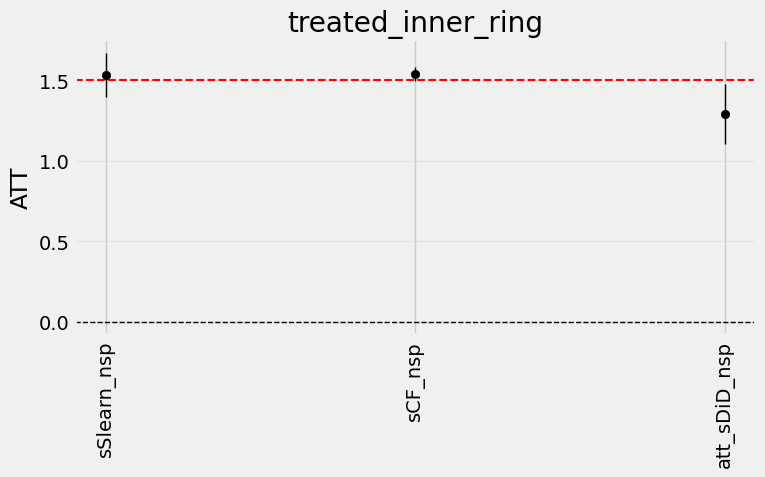

In [34]:
att_models_nsp_single = {
    "sSlearn_nsp": ("att_sSlearn_nsp", "se_sSlearn_nsp"),
    #"mLDML_sp": ("att_mLDML_sp", "se_mLDML_sp"),
    "sCF_nsp": ("att_sCF_nsp", "se_sCF_nsp"),
    "att_sDiD_nsp": ("att_sDiD_nsp", "se_sDiD_nsp"),

}

plot_att_row(
        df=df_single_effect_final_nsp,
        ring_name='treated_inner_ring',
        true_effect_col="true_effect",
        att_dict=att_models_nsp_single
    )

### Double treatment

#### S learner

In [35]:
RF_s_learner_nsp_DT = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate_slearn_multT_nsp_DT, lb_slearn_multT_nsp_DT, ub_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.estimate_ate(
    X_ns, T_Dbl, Y, return_ci = True)
ite_slearn_multT_nsp_DT = RF_s_learner_nsp_DT.fit_predict(X_ns, T_Dbl, Y)
ITE_df_slearn_multT_nsp_DT = pd.DataFrame(ite_slearn_multT_nsp_DT).rename(columns = {
                                            0:'treated_inner_ring', 1:'treated_outer_rings', 
                                             })
ITE_df_slearn_multT_nsp_DT['treated'] = T_M
df_dbl_treatment_effects_Slearn_nsp  = make_att_table(
    df=ITE_df_slearn_multT_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='Slearn_dblT'
)
df_double_vt_pre1 = df_effectbase.merge(df_dbl_treatment_effects_Slearn_nsp, on = 'ring', how= 'left')
df_double_vt_pre1

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT
0,treated_inner_ring,1.500000,1.678903,0.079561
1,treated_outer_ring1,1.049929,0.676931,0.075312
2,treated_outer_ring2,0.535380,0.297385,0.046876
3,treated_outer_ring3,0.123083,0.259080,0.041024


#### Causal forest

In [36]:
est2_cf_nsp_dt = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt.tune(Y, T_DT, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt.fit(Y, T_DT, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt = est2_cf_nsp_dt.const_marginal_effect(X_ns)
ITE_CF_nsp_DT=pd.DataFrame(te_pred2_nsp_dt ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT['treated'] = T_M


df_dbl_treatment_effects_CF  = make_att_table(
    df=ITE_CF_nsp_DT,
    inner_ring='treated_inner_ring',
    outer_rings=[
        'treated_outer_ring1',
        'treated_outer_ring2',
        'treated_outer_ring3'
    ],
    treated_col='treated',
    suffix='CF_dblT'
)
df_double_vt_pre2 = df_double_vt_pre1.merge(df_dbl_treatment_effects_CF, on = 'ring', how= 'left')
df_double_vt_pre2

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT
0,treated_inner_ring,1.500000,1.678903,0.079561,1.640934,0.027441
1,treated_outer_ring1,1.049929,0.676931,0.075312,0.448892,0.022509
2,treated_outer_ring2,0.535380,0.297385,0.046876,0.367865,0.031168
3,treated_outer_ring3,0.123083,0.259080,0.041024,0.357836,0.024888


#### Causal forest inverse distance

In [37]:
est2_cf_nsp_dt_id = CausalForestDML(model_y=RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(RandomForestRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2_cf_nsp_dt_id.tune(Y, T_DT_id, X=X_ns, 
          #W=W
          )
est2_cf_nsp_dt_id.fit(Y, T_DT_id, X=X_ns, 
         #W=W
         )

te_pred2_nsp_dt_id = est2_cf_nsp_dt_id.const_marginal_effect(X_ns)
ITE_CF_nsp_DT_id=pd.DataFrame(te_pred2_nsp_dt_id ).rename(columns = {0:'treated_inner_ring', 1:'treated_outer_rings', 

                                             })
ITE_CF_nsp_DT_id['treated'] = T_M

ITE_CF_nsp_DT_id['treated_outer_ring1'] = ITE_CF_nsp_DT_id['treated_outer_rings']
ITE_CF_nsp_DT_id['treated_outer_ring2'] = ITE_CF_nsp_DT_id['treated_outer_rings']/2
ITE_CF_nsp_DT_id['treated_outer_ring3'] = ITE_CF_nsp_DT_id['treated_outer_rings']/3


df_dbl_treatment_effects_CF_id = make_treatment_effects_df(ITE_CF_nsp_DT_id,  ['treated_inner_ring',
            'treated_outer_ring1',
             'treated_outer_ring2','treated_outer_ring3', 
             #'treated_outer_ring4'
             ],'CF_id', treated_col='treated')

# df_dbl_treatment_effects_CF_id  = make_att_table(
#     df=ITE_CF_nsp_DT_id,
#     inner_ring='treated_inner_ring',
#     outer_rings=[
#         'treated_outer_ring1',
#         'treated_outer_ring2',
#         'treated_outer_ring3'
#     ],
#     treated_col='treated',
#     suffix='CF_dblT_id'
# )
df_double_vt_final = df_double_vt_pre2.merge(df_dbl_treatment_effects_CF_id, on = 'ring', how= 'left')
df_double_vt_final

,ring,true_effect,att_Slearn_dblT,se_att_Slearn_dblT,att_CF_dblT,se_att_CF_dblT,att_CF_id,se_CF_id
0,treated_inner_ring,1.500000,1.678903,0.079561,1.640934,0.027441,1.646265,0.024103
1,treated_outer_ring1,1.049929,0.676931,0.075312,0.448892,0.022509,1.086013,0.036163
2,treated_outer_ring2,0.535380,0.297385,0.046876,0.367865,0.031168,0.495542,0.022540
3,treated_outer_ring3,0.123083,0.259080,0.041024,0.357836,0.024888,0.329739,0.012115


#### Results visualization

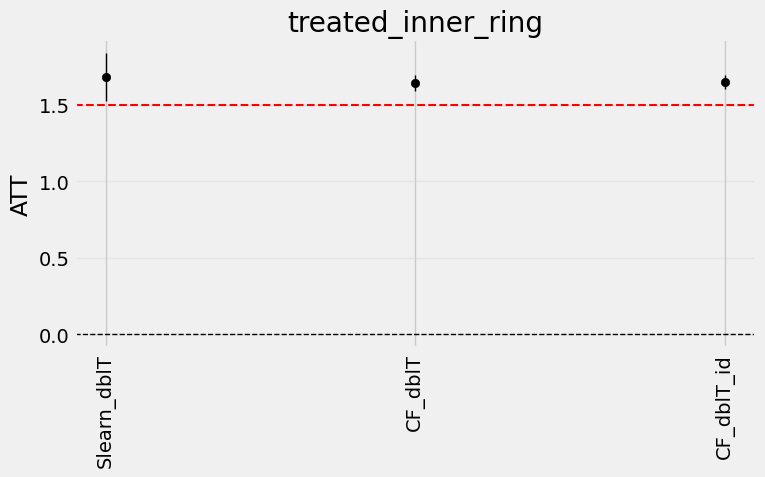

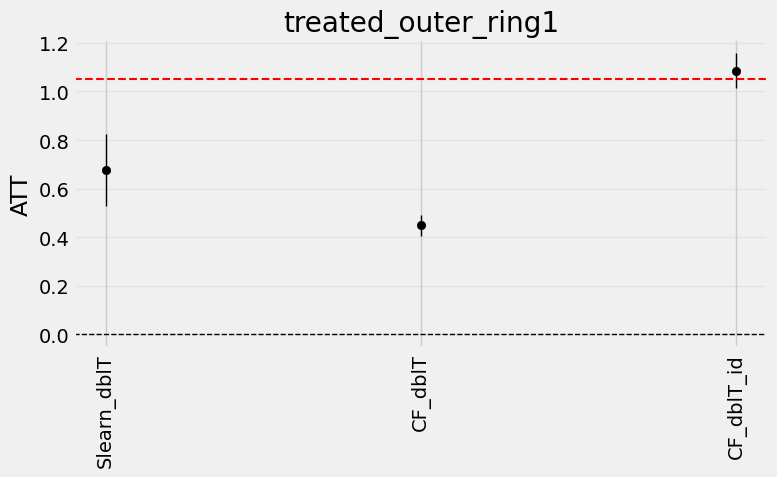

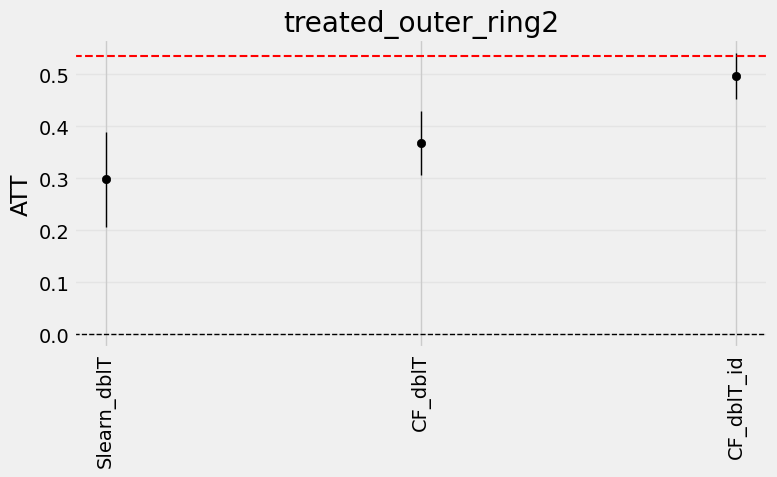

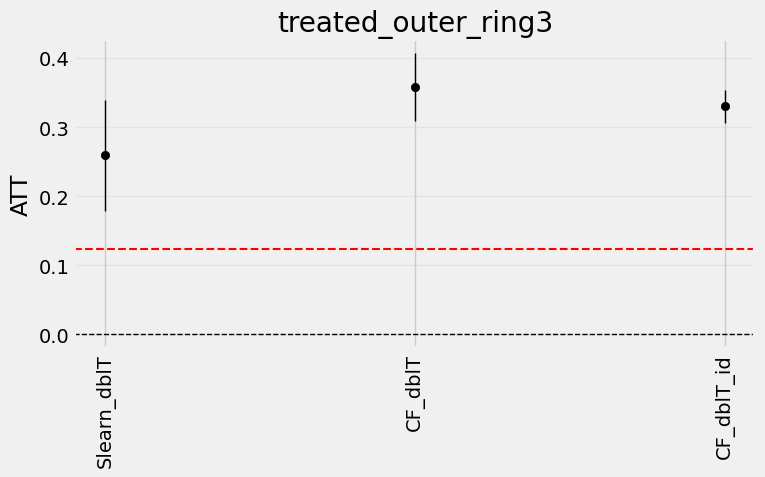

In [38]:
att_models_nspreg_id = {
    "Slearn_dblT": ("att_Slearn_dblT", "se_att_Slearn_dblT"),
    "CF_dblT": ("att_CF_dblT", "se_att_CF_dblT"),
    "CF_dblT_id": ("att_CF_id", "se_CF_id")
}
for ring in df_double_vt_final['ring'].unique().tolist():
    plot_att_row(
        df=df_double_vt_final,
        ring_name=ring,
        true_effect_col="true_effect",
        att_dict=att_models_nspreg_id
    )

## Loop

In [39]:
# features_non_spatial = ['c1', 'c2']
# list_of_effects_ik_dfs = []

# for i in df_names_list:

#     features_spatial = features_non_spatial+[c for c in dict_of_gdfs[i].columns.tolist() if 'spatial_predictor' in c]
#     X_non_sp = dict_of_gdfs[i][features_non_spatial].values
#     X_sp = dict_of_gdfs[i][features_spatial].values
#     Y =  dict_of_gdfs[i]['y'].values
#     T =  dict_of_gdfs[i]['t'].values

#     dict_of_forests = {
#         'cf_sp': X_sp,
#         'cf_nsp': X_non_sp
#     }
#     gdf_temp = dict_of_gdfs[i].copy()
#     list_of_effects_k_dfs = []
#     for k in dict_of_forests.keys():
#         est = CausalForestDML(model_t=RandomForestRegressor(),
#                         model_y=RandomForestRegressor(),
#                         n_estimators=180, #min_samples_leaf=5,
#                         max_depth=10,
#                         #verbose=0, 
#                         random_state=42)
#         est.fit(Y, T, X=dict_of_forests[k])
#         tau_hat_cf = est.effect(dict_of_forests[k])
#         gdf_temp[f'ITE_{k}'] = tau_hat_cf
#         tau_hat_cf_treated = gdf_temp[gdf_temp['t']==1][f'ITE_{k}'].copy()
#         att = tau_hat_cf_treated.mean()
#         se_att = tau_hat_cf_treated.std(ddof=1) / np.sqrt(len(tau_hat_cf_treated))
#         ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
#         df_result_temp = pd.DataFrame({'model_name': [f'{k}'],'ci_low_att':[ci_low_att], 'att':[att], 'ci_high_att':[ci_high_att], 'rho': float('0.'+i[10:])})
#         list_of_effects_k_dfs.append(df_result_temp)
#     df_cf_att_i = pd.concat(list_of_effects_k_dfs)
#     list_of_effects_ik_dfs.append(df_cf_att_i)
# df_cf_att = pd.concat(list_of_effects_ik_dfs)

# Results visualization

In [40]:
# df_sp = df_cf_att[df_cf_att['model_name'] == 'cf_sp'].copy()
# df_nsp = df_cf_att[df_cf_att['model_name'] == 'cf_nsp'].copy()

# # lekkie przesunięcie na osi X
# offset = 0.01
# df_sp['rho_shift'] = df_sp['rho'] - offset
# df_nsp['rho_shift'] = df_nsp['rho'] + offset

# fig, ax = plt.subplots(figsize=(8, 5))

# # --- cf_sp (zielony) ---
# ax.scatter(df_sp['rho_shift'], df_sp['att'], color='green', label='cf_sp', zorder=3)

# ax.vlines(
#     x=df_sp['rho_shift'],
#     ymin=df_sp['ci_low_att'],
#     ymax=df_sp['ci_high_att'],
#     color='green',
#     linewidth=3
# )

# # --- cf_nsp (niebieski) ---
# ax.scatter(df_nsp['rho_shift'], df_nsp['att'], color='blue', label='cf_nsp', zorder=3)

# ax.vlines(
#     x=df_nsp['rho_shift'],
#     ymin=df_nsp['ci_low_att'],
#     ymax=df_nsp['ci_high_att'],
#     color='blue',
#     linewidth=3
# )

# # pozioma linia odniesienia
# ax.axhline(y=1.5, color='red', linestyle='--')

# # opisy
# ax.set_xlabel('rho')
# ax.set_ylabel('ATT')
# ax.legend()

# plt.tight_layout()
# plt.show()